In [55]:
# The Random Forest gives use Low Bias and Low Variance model
# Because there are multiple decision trees, in decision tree it is already a low bias model but when we use multiple decision trees
# then the difference of error spread out to all the tree that's why in result we got low variance model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [27]:
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [29]:
X_train.shape

(400, 2)

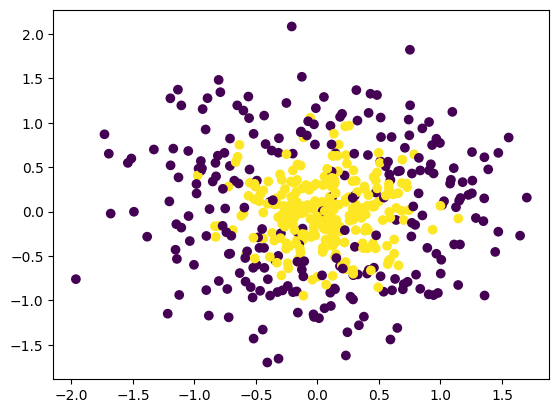

In [30]:
plt.scatter(X[:,0], X[:,1], c=y)

In [31]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

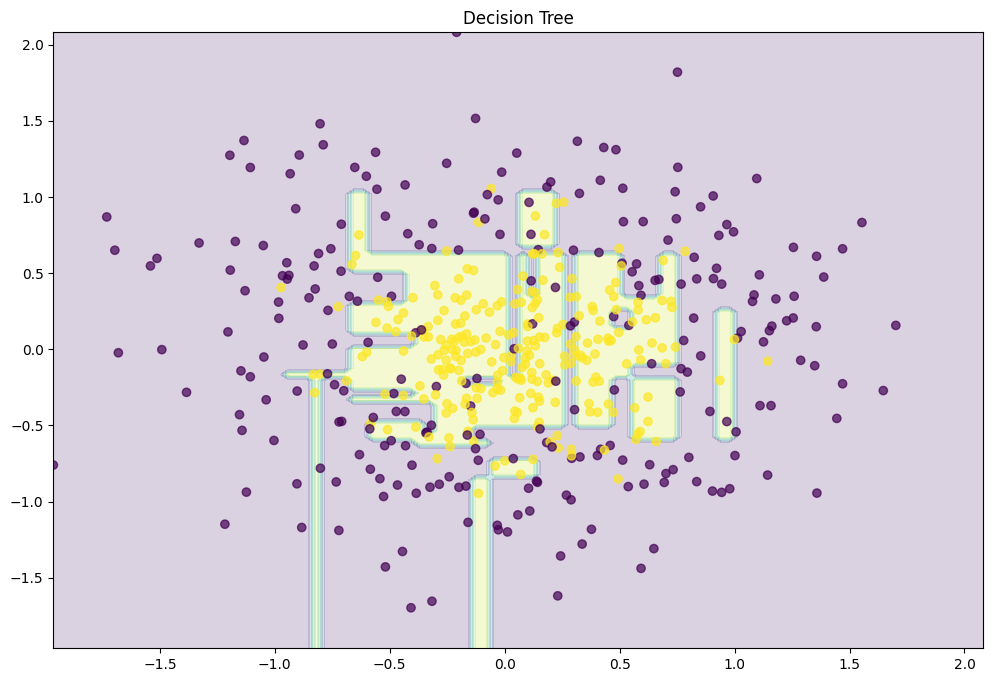

In [34]:
plt.figure(figsize=(12,8))
X_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(X_range, X_range)
y_hat = dt.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", alpha=0.7)
plt.title("Decision Tree")
plt.show()

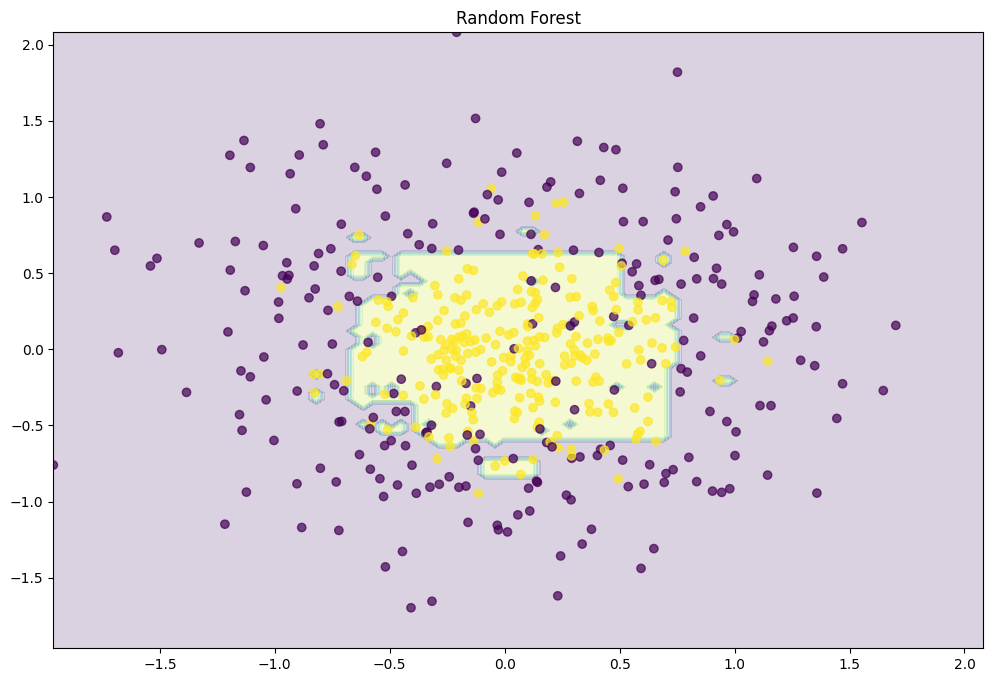

In [36]:
rf = RandomForestClassifier(n_estimators=500, random_state=23)
rf.fit(X_train, y_train)

plt.figure(figsize=(12,8))
X_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(X_range, X_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", alpha=0.7)
plt.title("Random Forest")
plt.show()

In [37]:
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x-2) ** 2)

In [42]:
n_train = 150
n_test = 500
noise = 0.1

def genrate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5 
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X-2) ** 2) + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = genrate(n_samples=n_train, noise=noise)
X_test, y_test = genrate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

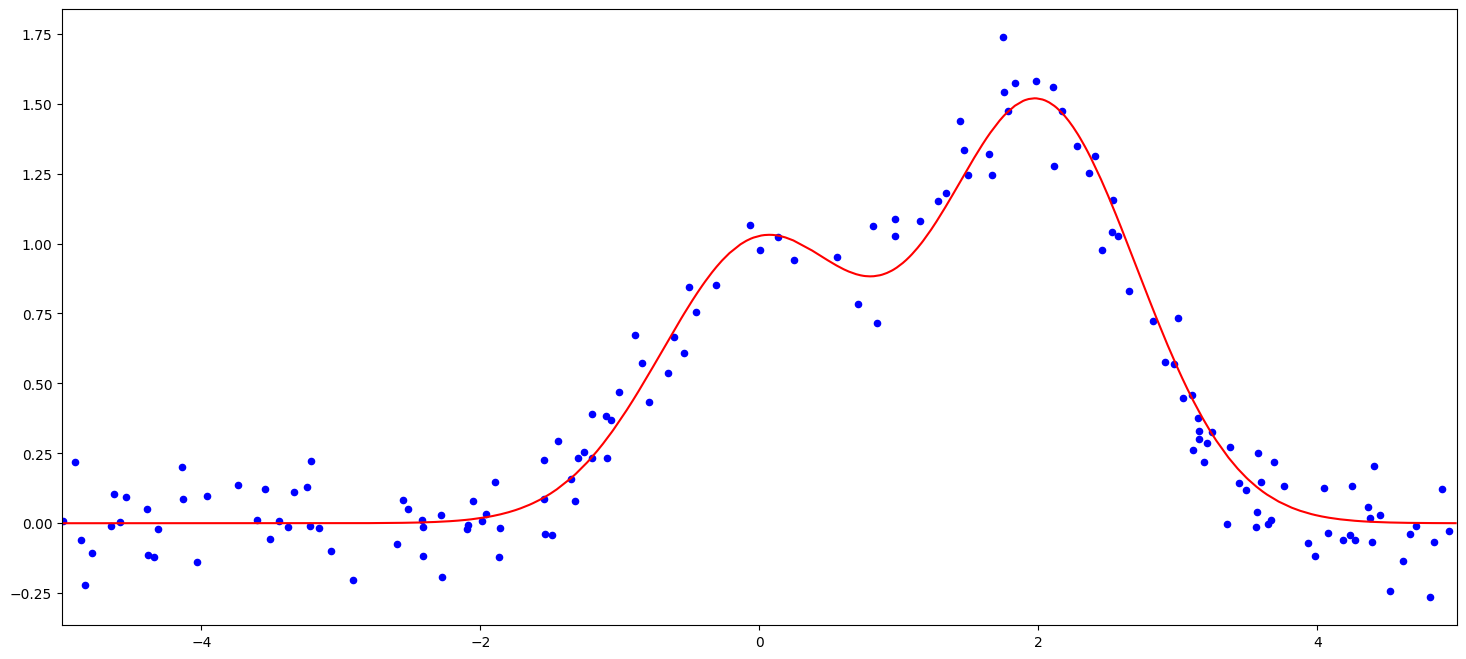

In [43]:
plt.figure(figsize=(18,8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5,5])

In [44]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)

DecisionTreeRegressor()

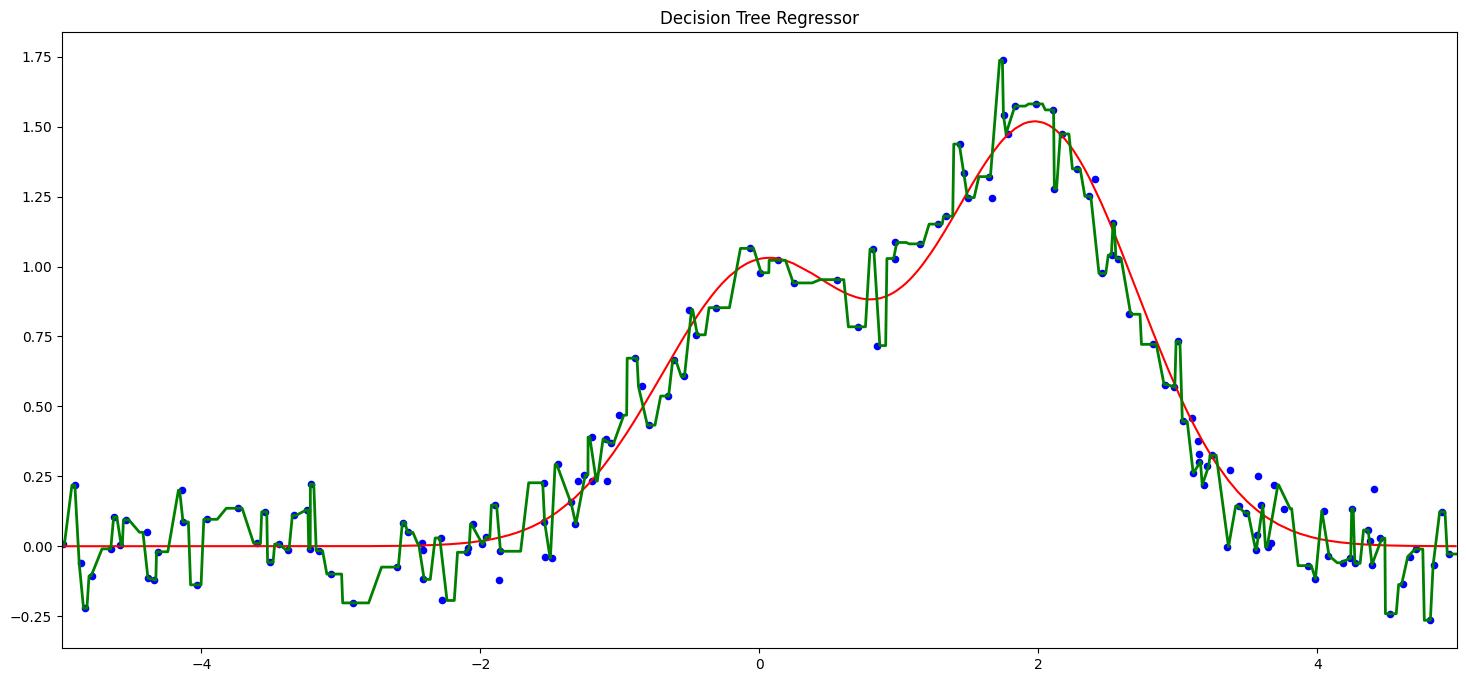

In [45]:
d_predict = dtr.predict(X_test)

plt.figure(figsize=(18,8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5,5])
plt.title("Decision Tree Regressor")
plt.show()

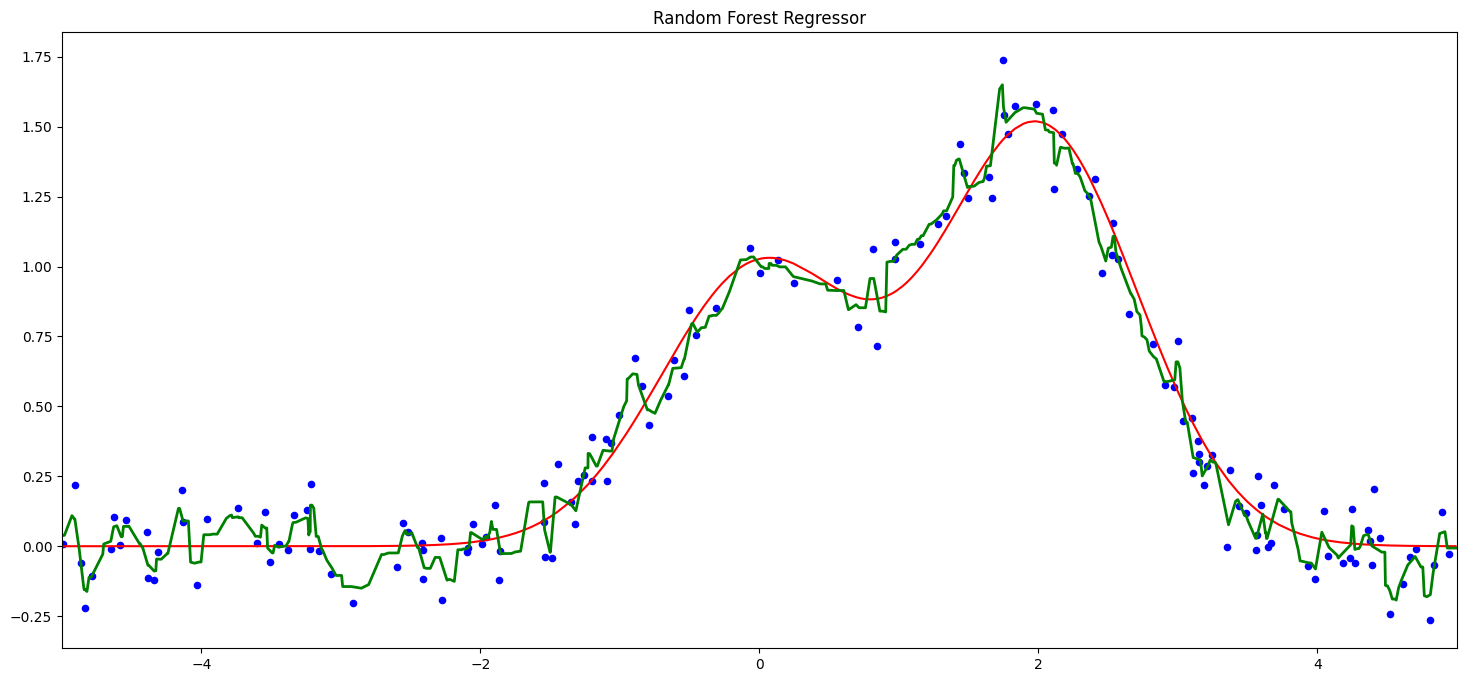

In [54]:
rfr = RandomForestRegressor(n_estimators=500)
rfr.fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18,8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5,5])
plt.title("Random Forest Regressor")
plt.show()